# K Nearest Neighbor

In my previous aritcles on `machine learning` algorithms I talked about `linear regression` and `logistic regression`. These two algorithms are `same same, but different` and also they are linear algorithms. So, Let's talk about a `non-linear algorithm` called `K Nearest Neighbor` (KNN).



# Introduction

`K nearest neighbor` is a very special algorithm that opened up a whole new world of possibilities for `machine learning` algorithms. It can be used for both `classification` and `regression` problems.

Unlike other machine learning algorithms `KNN` is not dependent on the relation between the `features` and the `target variable`. 

It is dependent on the `distance` between the `features` and the `target variable`.

Now, what do I mean by distance?

## Internal Workings of KNN

Let's say we have dataset Like below:

In [1]:
import numpy as np
import pandas as pd

np.random.seed(4)

# Class A cluster
A_x1 = np.random.normal(loc=3, scale=0.3, size=10)
A_x2 = np.random.normal(loc=3, scale=0.3, size=10)

# Class B cluster
B_x1 = np.random.normal(loc=4, scale=0.3, size=10)
B_x2 = np.random.normal(loc=4, scale=0.3, size=10)

df = pd.DataFrame({
    "Feature_1": np.concatenate([A_x1, B_x1]),
    "Feature_2": np.concatenate([A_x2, B_x2]),
    "Target": ["Class_A"] * 10 + ["Class_B"] * 10
})

df.head()


,Feature_1,Feature_2,Target
0,3.015169,3.185601,Class_A
1,3.149985,2.973604,Class_A
2,2.701227,3.127522,Class_A
3,3.208080,3.099676,Class_A
4,2.874510,2.652955,Class_A


Here, I made a synthetic dataset for KNN demonstration.

This dataset has two features `Feature_1` and `Feature_2` and one target variable `Target`.

The `target` variable has two classes `Class_A` and `Class_B`.

So, it's a categorical variable. The `KNN` algorithm is going to predict the `target` variable based on the `features`.

So, let's do some data visualization.

Let's see if there's any `relations` between the `features`.

As both the `features` are continuous variables, we can use `scatter plot` to visualize the relationship between the `features`.

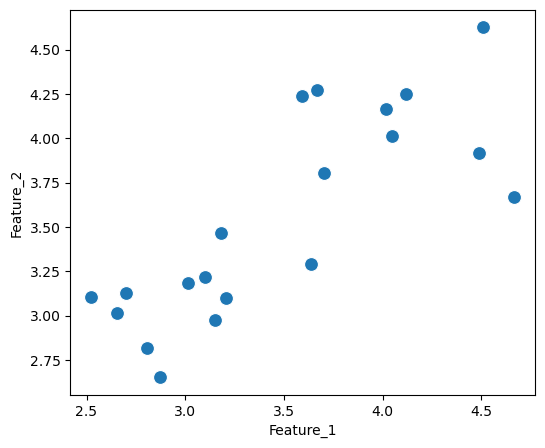

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="Feature_1",
    y="Feature_2",
    s=100,
)
plt.show()


The well, we can clearly cannot see any relationship between the `features`. The data is fully scattered and we cannot specify any clear relations between the `features`.

But here's the twist.

> Just set hue. Try it. Something interesting will happen.

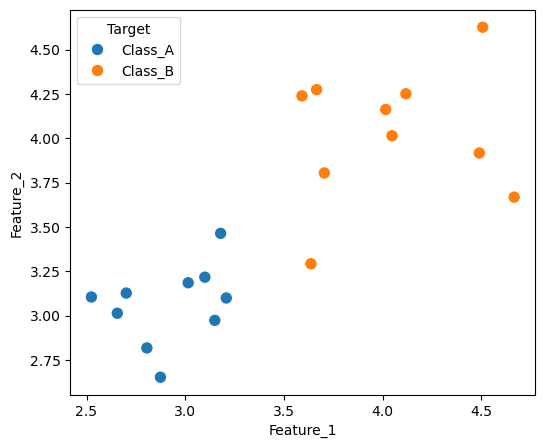

In [3]:

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="Feature_1",
    y="Feature_2",
    hue="Target",
    s=80,
)

plt.show()

Woh! Where did that come from?

Even though there is no well defined relationship between the `features` there is a clear distinction between the `classes` `Class_A` and `Class_B`.

So, as you can see here there is a partition between the two classes.

So, Let's do a thought experiment.

What if there is a new datapoint like below? in the scatter plot.


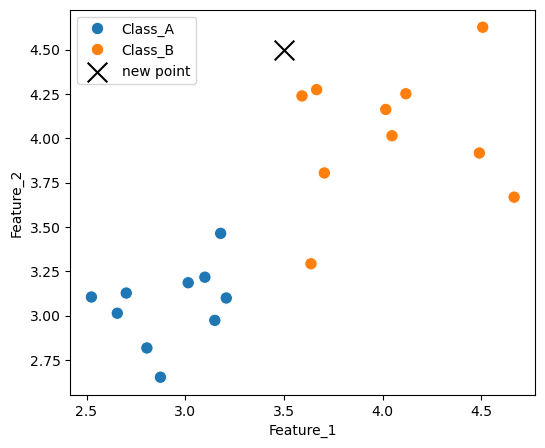

In [4]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="Feature_1",
    y="Feature_2",
    hue="Target",
    s=80,
)

plt.scatter(
    x=[3.5],
    y=[4.5],
    c="black",
    s=200,
    marker="x",
    label='new point'
)

plt.legend()

Which class do you think this new datapoint belongs to?

We can say it belongs to `Class_B` because it is far away from `Class_A` datapoints and surrounded by `Class_B` datapoints.

Same goes for this `datapoint` below.

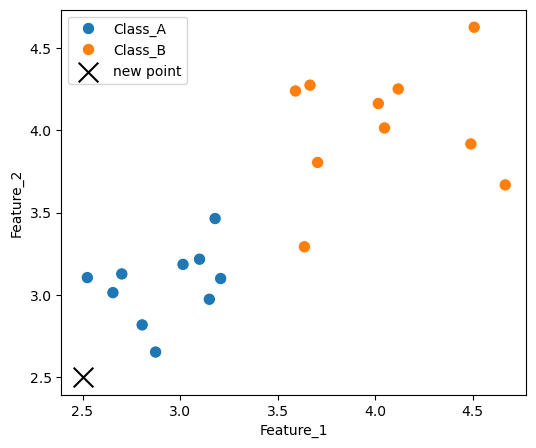

In [5]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="Feature_1",
    y="Feature_2",
    hue="Target",
    s=80,
)

plt.scatter(
    x=[2.5],
    y=[2.5],
    c="black",
    s=200,
    marker="x",
    label='new point'
)

plt.legend()

We can say that this new datapoint belongs to `Class_A` because it is far away from `Class_B` datapoints and surrounded by `Class_A` datapoints.

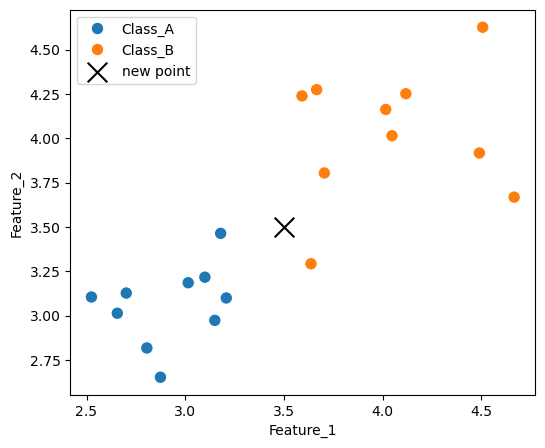

In [6]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="Feature_1",
    y="Feature_2",
    hue="Target",
    s=80,
)

plt.scatter(
    x=[3.5],
    y=[3.5],
    c="black",
    s=200,
    marker="x",
    label='new point'
)

plt.legend()

Now, what about this new datapoint?

Now, we have a dilemma.

This data point is exactly in between the `Class_A` and `Class_B` datapoints.

How, do we decide which class it belongs to?

This is the driving force of `K nearest neighbor` algorithm.

We recognised which class a datapoint belongs to by looking at the `neighbors` of the datapoint.

If the datapoint is surrounded by `Class_A` datapoints then it belongs to `Class_A` and if the datapoint is surrounded by `Class_B` datapoints then it belongs to `Class_B`.

Simple intuition right?

So, let's get into the details of `K nearest neighbor` algorithm.

## Desicion Making with KNN

In this algorithm we use `distance` to decide which `class` a datapoint belongs to.

- First we measure the `distance` between the `datapoint` and all the `datapoints` in the dataset.

- And we `sort` the distance in `ascending` order.

- Then we take the first `K` datapoints with the `smallest` distance. This is why it's called `K nearest neighbor`.

- And we decide which `class` they belong to.

How do we decide?

WE USE THE `MAJORITY VOTE`!

First time hearing this term?

_`Majority voting` is a voting system in which the `candidate` with the `highest` number of `votes` is declared the `winner`._

Suppose, you have a datapoint that has `5 neighbors`.

THe neighbors are `Class_A`, `Class_B`, `Class_A`, `Class_A` and `Class_B`.


As `class_A` has `3 votes` and `class_B` has `2 votes` then `class_A` is the winner.

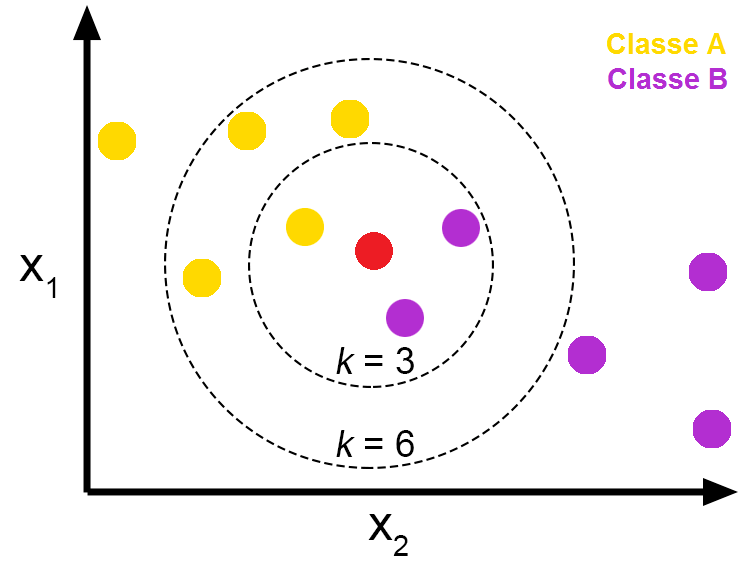

I think this image describes `K nearest neighbor` algorithm very well.

So, let's mathematically see which `class` a datapoint belongs to.

## The Math Behind KNN

Let's say out new datapoint is [3.5, 3.5] and we want find a `class` for it.

So, step 1: Find the distance between the new datapoint and all the datapoints in the dataset.

In [7]:
import numpy as np
import pandas as pd

data_point = np.array([3.5, 3.5])

# Euclidean distance for each row
df['Distance'] = np.sqrt(
    (df['Feature_1'] - data_point[0])**2 +
    (df['Feature_2'] - data_point[1])**2
)

df


,Feature_1,Feature_2,Target,Distance
0,3.015169,3.185601,Class_A,0.577848
1,3.149985,2.973604,Class_A,0.632142
2,2.701227,3.127522,Class_A,0.881350
3,3.208080,3.099676,Class_A,0.495456
4,2.874510,2.652955,Class_A,1.052959
5,2.524627,3.105299,Class_A,1.052208
6,2.805688,2.817934,Class_A,0.973285
7,3.179573,3.464094,Class_A,0.322433
8,3.099675,3.217002,Class_A,0.490253
9,2.655757,3.013841,Class_A,0.974216


Here, we see the `euclidean distance` between the `new datapoint` and all the `datapoints` in the dataset.

And next step is to `sort` the distance in `ascending` order.

In [8]:
df.sort_values(by='Distance', inplace=True)
df

,Feature_1,Feature_2,Target,Distance
13,3.637316,3.292578,Class_B,0.248756
7,3.179573,3.464094,Class_A,0.322433
10,3.705103,3.804632,Class_B,0.367244
8,3.099675,3.217002,Class_A,0.490253
3,3.208080,3.099676,Class_A,0.495456
0,3.015169,3.185601,Class_A,0.577848
1,3.149985,2.973604,Class_A,0.632142
19,3.591710,4.238954,Class_B,0.744623
12,4.047968,4.014402,Class_B,0.751584
17,3.666156,4.274452,Class_B,0.792076


And we are ready to find which class the new datapoint belongs to.

But first let's talk about the distance function.

You can use two distance functions.

- Euclidean distance.

$$
d(x, y) = \sqrt{(x_1 - y_1)^2 + (x_2 - y_2)^2}
$$

Here, `x` and `y` are the data points positions.

- Manhattan distance.

$$
d(x, y) = |x_1 - y_1| + |x_2 - y_2|
$$

Both distance functions can be used for `K nearest neighbor` algorithm.

`Euclidean distance` is the direct distance between the datapoints.

`Manhattan distance` is the distance between the datapoints in the `horizontal` and `vertical` direction.

> By default, `Euclidean distance` is used in `K nearest neighbor` algorithm.

Now, let's see which `class` the new datapoint belongs to.

We take `k` number of datapoints with the `smallest` distance.

Let's say k is 1.

So, the smallest distance to the `new datapoint` itself is class `B`.

What if k is 3?

Three smallest distances are `Class_B`, `Class_A` and `Class_B`.

So, by majority voting, `Class_B` wins.

And one last time let's see k is 5.

5 smallest distances are `Class_B`, `Class_A`, `Class_B`, `Class_A` and `Class_A`.

So, by majority voting, `Class_A` wins.

Wow, If we take k=1 then we get `Class_B` and if we take k=5 then we get `Class_A`.

So, which one we should take?

It depends on the `problem` we are solving.

And experimentation of different `k` values can help us find the best `k` value.

Selecting the best `k` value can be a tedious process.

Just remember these two things:

- High `k` can lead to overfitting.
- Low `k` can lead to underfitting.

So, try it out with different `k` values to find out the sweet spot.

## Pros & Cons

Pros:

- Easy to implement.
- Can be used for both `classification` and `regression` problems.
- Intuive and easy to understand.
- Purely statistical approach and has no underlying assumptions.
- Has reasonable accuracy.
- Can be used for both `small` and `large` datasets.
- Doesn't need any contextual information of the data.

However, there are some cons:

- Can be sensitive to the choice of `k`.
- Computationally expensive.
- Performance can degrade with large number of features.
- Can be affected by outliers/noise.
- Struggles with imbalanced datasets.

Wow, some many pros and so many cons. But it's a very easy algorithm to get your mind around and use. So, let's make use `k nearest neighbor` algorithm for a dataset.

# Let's Make a model

First collecting the data.

## Data Collection

You can find the data set for this article in my [github repo](https://github.com/RishatTalukder/Machine-Learning-Zero-to-Hero).

I'll be using this dataset.

In [9]:
import pandas as pd

data = pd.read_csv('Classified Data.txt', index_col=0)

data.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


Now, If you look at this data, there are no understandable features/labels.

This is because `KNN` doesn't need any context of the data.

KNN does not understand the meaning or units of the data.
It only works by measuring the distance between data points in a feature space.

Because of this, the **scale of features becomes extremely important**.

For example, consider a dataset with features like `cost`, `area`, and `height`.
These features are measured in different units such as currency, square meters, and feet.

If we directly use these values without preprocessing, features with larger numeric ranges (like cost) will dominate the distance calculation. As a result, KNN may `ignore` other important features.

To ensure that each feature contributes fairly to the distance computation, we need to **scale or normalize the features to a comparable numeric range**.

This does not change the meaning of the data, but it makes distance-based algorithms like KNN behave correctly.

Additionally, KNN can struggle in high-dimensional spaces, a phenomenon known as the **curse of dimensionality**, where distances become less meaningful and model performance degrades.

So, we need to scale the features.

## Feature Scaling

`Scaling` is the process of `transforming` feature values so that they lie on a `comparable numerical scale`, **without changing their relative relationships**.
This ensures that all features contribute fairly to distance-based calculations while preserving the underlying structure of the data

Simply put, Scaling transforms feature values to a `similar numeric range` so that **no single feature dominates the model due to its magnitude**, while keeping the relative relationships between data points intact. 

> In KNN, scaling is necessary because distance calculations depend on magnitude, not meaning.

There are several ways to scale features, but the most common ones are:

- `Standardization`.
- `Normalization/Min-Max`.

### Standardization

`Standardization` is a method of scaling features by `subtracting` the `mean` and `dividing` by the `standard deviation` of each feature.

This way all the features will have:

- A `mean` close to 0.(Sometimes it is `0`)
- A `standard deviation` close to 1.(Sometimes it is completely `1`)

The equation for standardization is:

$$
x_{standardized} = \frac{x - \mu}{\sigma}
$$

where $x$ is the original value, $\mu$ is the mean, and $\sigma$ is the standard deviation.

This transformation ensures that all features have a similar magnitude, but the relative relationships between data points are preserved.

### Normalization

`Normalization` is a method of scaling features by `dividing` each feature by its `maximum value` minus its `minimum value`.

This way all the features will have:

- A `minimum value` of 0.
- A `maximum value` of 1.

The equation for normalization is:  

$$
x_{normalized} = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

where $x$ is the original value.

This transformation also ensures that all features have a similar magnitude, but the relative relationships between data points are preserved.

These two scaling methods are the most common ones used not only for `KNN` but also for many other machine learning algorithms.

> Scaling the features is a good practice, because it ensures that all the features contribute fairly to the algorithms. Try to scale the features for other algorithms I thought in this article series like `linear regression or logistic regression`.

I'll use `Standardization` in this article.

## Scaling the Data

`Sci-kit learn` has a lot of functions in the `preprocessing` module that we can use to scale the data.

One of them is `StandardScaler()`.

Let's standardize the data.

First we need all the features.

> Don't ever scale the target variable.

In [10]:
from sklearn.preprocessing import StandardScaler

features = data.drop(columns='TARGET CLASS')
target = data['TARGET CLASS']
scaler = StandardScaler()

It works almost like the `machine learning` models.

We can fit the features to the scaler and then use another method called `transform` to get a fully scaled features set.

In [11]:
scaler.fit(features)

,copy,True
,with_mean,True
,with_std,True


Now we transform the features.

In [12]:
scaler.transform(features)

array([[-0.12354188,  0.18590747, -0.91343069, ..., -1.48236813,
        -0.9497194 , -0.64331425],
       [-1.08483602, -0.43034845, -1.02531333, ..., -0.20224031,
        -1.82805088,  0.63675862],
       [-0.78870217,  0.33931821,  0.30151137, ...,  0.28570652,
        -0.68249379, -0.37784986],
       ...,
       [ 0.64177714, -0.51308341, -0.17920486, ..., -2.36249443,
        -0.81426092,  0.11159651],
       [ 0.46707241, -0.98278576, -1.46519359, ..., -0.03677699,
         0.40602453, -0.85567   ],
       [-0.38765353, -0.59589427, -1.4313981 , ..., -0.56778932,
         0.3369971 ,  0.01034996]], shape=(1000, 10))

It'll return a numpy array with all the features scaled.

If you want you can make a dataframe out of it. But we can directly pass it to the model.

Also, there is another method we get that can do the whole fitting and transforming the data at once.

In [13]:
scaler.fit_transform(features)

array([[-0.12354188,  0.18590747, -0.91343069, ..., -1.48236813,
        -0.9497194 , -0.64331425],
       [-1.08483602, -0.43034845, -1.02531333, ..., -0.20224031,
        -1.82805088,  0.63675862],
       [-0.78870217,  0.33931821,  0.30151137, ...,  0.28570652,
        -0.68249379, -0.37784986],
       ...,
       [ 0.64177714, -0.51308341, -0.17920486, ..., -2.36249443,
        -0.81426092,  0.11159651],
       [ 0.46707241, -0.98278576, -1.46519359, ..., -0.03677699,
         0.40602453, -0.85567   ],
       [-0.38765353, -0.59589427, -1.4313981 , ..., -0.56778932,
         0.3369971 ,  0.01034996]], shape=(1000, 10))

We can directly use this to scale our features. So, let's store this scaled features in a variable and let's train a `K nearest neighbor` model.

In [14]:
scaled_features = scaler.fit_transform(features)

Let's split the data into train and test sets.

## Model Training

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(scaled_features, target, test_size=0.3, random_state=42)

Now we import the `K nearest neighbor` model.

In [16]:
from sklearn.neighbors import KNeighborsClassifier

Like every other model we have to initialize it and unlike any other model we learned in this article series we can pass a parameter called `n_neighbors` to it.

> The `n_neighbors` parameter is the number of neighbors to consider when making predictions.

In [17]:
KNN = KNeighborsClassifier(n_neighbors=1)

Now, we fit.

In [18]:
KNN.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


And we can predict.

In [19]:
predictions = KNN.predict(X_test)
predictions

array([0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0])

We have our predictions ready and like always we test them.

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       142
           1       0.95      0.93      0.94       158

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



Woh! `94%!`

With only one neighbor, we get 94% accuracy.

I have to say amazing. No data analysis, no context on what the data represents, just a intuitive process and a `K nearest neighbor` model and we get 94% accuracy!

Now, I'm curious what happens if we use more neighbors.

Finding the best number of neighbors is a very important step in `K nearest neighbor` algorithm.

## Finding the Best K

We can use `cross-validation` to find the best number of neighbors.

We will use a mathod called the `elbow method` to find the best number of neighbors.

> Bruteforce iteration of neighbors to find the best number of neighbors.

We will just make multiple models for multiple neighbors and then choose the best one.

In [21]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)

0.9366666666666666

Our model with `k=1` has an accuracy of `93.666%`.

> You can use the `accuracy_score` function to get the accuracy of the model.

So, let's now find the best number of neighbors.

In [22]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# odd k values from 1 to 39
k_values = range(1, 40, 2)

test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    test_scores.append(acc)

# best k
best_k = k_values[np.argmax(test_scores)]
best_score = max(test_scores)

print(f"Best k: {best_k}")
print(f"Test accuracy: {best_score:.4f}")


Best k: 13
Test accuracy: 0.9533


Well, the best k is 13.

Let's see if this is the best we actually get.

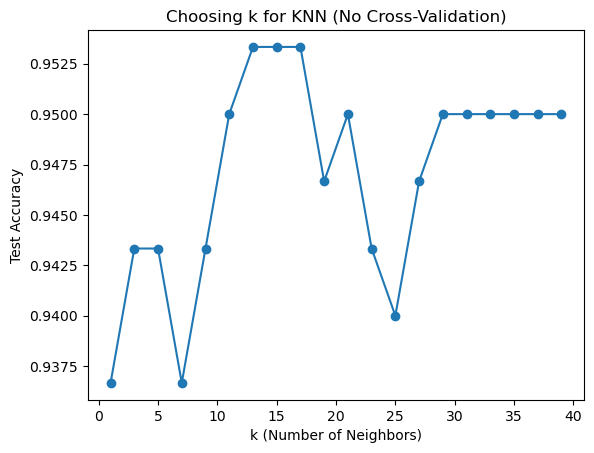

In [23]:
import matplotlib.pyplot as plt

plt.plot(k_values, test_scores, marker='o')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.title("Choosing k for KNN (No Cross-Validation)")
plt.show()
